# TP1 — EDA & Nettoyage du Dataset Lumina & Co

> **Contexte** : Le data engineer de Lumina & Co nous a livré deux fichiers extraits du CRM : `customers.csv` et `transactions.csv`. Avant toute segmentation, nous devons comprendre la structure des données, documenter leurs anomalies et les corriger de manière rigoureuse.

---

## Sommaire
1. [Chargement & Inspection initiale](#etape1)
2. [Data Quality Report](#dqr)
3. [Détection & Traitement des anomalies](#etape2)
4. [EDA orientée marketing](#etape3)
5. [Hypothèses marketing](#etape4)

---
## Étape 1 — Chargement & Inspection initiale <a id='etape1'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

# Style global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14

# Chargement
customers = pd.read_csv('customers.csv')
transactions = pd.read_csv('transactions.csv')

print('=== CUSTOMERS ===')
print(f'Lignes : {customers.shape[0]:,}  |  Colonnes : {customers.shape[1]}')
print('\n=== TRANSACTIONS ===')
print(f'Lignes : {transactions.shape[0]:,}  |  Colonnes : {transactions.shape[1]}')

=== CUSTOMERS ===
Lignes : 50,000  |  Colonnes : 9

=== TRANSACTIONS ===
Lignes : 1,837,137  |  Colonnes : 8


### 1.1 Aperçu structurel

In [2]:
print('=== customers.csv — Premières lignes ===')
display(customers.head(5))

print('\n=== transactions.csv — Premières lignes ===')
display(transactions.head(5))

=== customers.csv — Premières lignes ===


,customer_id,country,first_purchase,last_purchase,n_orders,total_spent,avg_basket,recency_days,tenure_days
0,46995,United Kingdom,2011-08-09 12:20:00,2011-11-16 12:20:00,2.28,57.34,26.44,23.83,99.17
1,22869,United Kingdom,2010-01-11 12:20:00,2011-10-30 12:20:00,46.53,19463.52,356.65,40.92,657.12
2,12593,France,2011-05-05 09:29:00,2011-05-05 09:29:00,1.00,39.50,39.50,218.00,218.00
3,25889,United Kingdom,2008-07-14 12:20:00,2010-02-22 12:20:00,0.98,24.53,25.15,655.23,588.26
4,52931,United Kingdom,2009-08-29 12:20:00,2010-11-04 12:20:00,2.00,47.80,23.18,400.35,432.64



=== transactions.csv — Premières lignes ===


,invoice_id,customer_id,product_code,product_name,quantity,unit_price,invoice_date,country
0,513574,NaN,22382,LUNCH BAG SPACEBOY DESIGN,2.0,4.21,2010-06-25 15:13:00,United Kingdom
1,609421,NaN,21028,PURPLE GEMSTONE BRACELET,2.0,8.95,2011-10-16 12:20:00,United Kingdom
2,515609,NaN,47591B,SCOTTIES CHILDRENS APRON,1.0,1.66,2010-07-13 15:44:00,United Kingdom
3,501320,15123.0,22334,DINOSAUR PARTY BAG + STICKER SET,8.0,1.65,2010-03-16 09:49:00,United Kingdom
4,521822,12714.0,21933,PINK VINTAGE PAISLEY PICNIC BAG,5.0,2.95,2010-09-09 10:37:00,France


In [3]:
print('=== TYPES DE DONNÉES — customers ===')
display(customers.dtypes.rename('dtype_observé').to_frame())

print('\n=== TYPES DE DONNÉES — transactions ===')
display(transactions.dtypes.rename('dtype_observé').to_frame())

=== TYPES DE DONNÉES — customers ===


,dtype_observé
customer_id,int64
country,str
first_purchase,str
last_purchase,str
n_orders,float64
total_spent,float64
avg_basket,float64
recency_days,float64
tenure_days,float64



=== TYPES DE DONNÉES — transactions ===


,dtype_observé
invoice_id,str
customer_id,float64
product_code,str
product_name,str
quantity,float64
unit_price,float64
invoice_date,str
country,str


In [4]:
# Conversion des colonnes dates
customers['first_purchase'] = pd.to_datetime(customers['first_purchase'])
customers['last_purchase']  = pd.to_datetime(customers['last_purchase'])
transactions['invoice_date'] = pd.to_datetime(transactions['invoice_date'])

print('Conversions datetime effectuées.')

Conversions datetime effectuées.


### 1.2 Questions fondamentales avant nettoyage

In [5]:
# Combien de clients ? Combien de transactions ? Sur quelle période ?
n_customers_crm = customers['customer_id'].nunique()
n_customers_txn = transactions['customer_id'].dropna().nunique()
n_transactions  = len(transactions)
n_invoices      = transactions['invoice_id'].nunique()
period_start    = transactions['invoice_date'].min()
period_end      = transactions['invoice_date'].max()

print(f"""📊 CHIFFRES CLÉS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Clients dans le CRM          : {n_customers_crm:,}
Clients distincts (txn)      : {n_customers_txn:,}
Lignes de transactions       : {n_transactions:,}
Factures uniques             : {n_invoices:,}
Période                      : {period_start.date()} → {period_end.date()}
Durée                        : {(period_end - period_start).days} jours
""")

📊 CHIFFRES CLÉS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Clients dans le CRM          : 50,000
Clients distincts (txn)      : 49,146
Lignes de transactions       : 1,837,137
Factures uniques             : 253,545
Période                      : 2007-07-06 → 2011-12-09
Durée                        : 1617 jours



In [6]:
# Valeurs manquantes
def missing_report(df, name):
    missing = pd.DataFrame({
        'n_missing': df.isna().sum(),
        'pct_missing': (df.isna().mean() * 100).round(2)
    })
    missing = missing[missing['n_missing'] > 0].sort_values('pct_missing', ascending=False)
    print(f'=== Valeurs manquantes — {name} ===')
    if missing.empty:
        print('Aucune valeur manquante détectée.')
    else:
        display(missing)

missing_report(customers, 'customers.csv')
print()
missing_report(transactions, 'transactions.csv')

=== Valeurs manquantes — customers.csv ===
Aucune valeur manquante détectée.

=== Valeurs manquantes — transactions.csv ===


,n_missing,pct_missing
customer_id,418258,22.77
quantity,16187,0.88
product_name,7542,0.41


In [7]:
# Doublons
dup_customers    = customers.duplicated().sum()
dup_transactions = transactions.duplicated().sum()
dup_txn_key      = transactions.duplicated(subset=['invoice_id','product_code','quantity','unit_price']).sum()

print(f'Doublons exacts (customers)           : {dup_customers}')
print(f'Doublons exacts (transactions)        : {dup_transactions}')
print(f'Doublons fonctionnels (txn, clé métier): {dup_txn_key}')

Doublons exacts (customers)           : 0
Doublons exacts (transactions)        : 34522
Doublons fonctionnels (txn, clé métier): 34701


---
## Étape 2 — Data Quality Report (pré-nettoyage) <a id='dqr'></a>

>  **Principe** : *Un biais non documenté est un biais invisible.* Nous documentons d'abord, nous traitons ensuite.

In [8]:
# ═══ OBSERVATION 1 — customer_id manquants dans transactions ═══
n_anon = transactions['customer_id'].isna().sum()
pct_anon = n_anon / len(transactions) * 100
print(f"[OBS 1] Transactions anonymes (customer_id manquant) : {n_anon:,} ({pct_anon:.2f}%)")
print("        → Ces lignes représentent des achats d'invités (guest checkout).")
print("        → Elles ont un chiffre d'affaires réel : ne pas supprimer, mais isoler.\n")

# ═══ OBSERVATION 2 — Quantités négatives ═══
n_qty_neg = (transactions['quantity'] < 0).sum()
pct_qty_neg = n_qty_neg / len(transactions) * 100
print(f"[OBS 2] Lignes à quantity négative : {n_qty_neg:,} ({pct_qty_neg:.2f}%)")
print("        → Ce sont des retours/avoirs (credit notes). Identifiables car invoice_id commence souvent par 'C'.")
print("        → Impact sur les agrégations : total_spent surestimé si non traité.\n")

# ═══ OBSERVATION 3 — unit_price à zéro ═══
n_price_zero = (transactions['unit_price'] == 0).sum()
pct_price_zero = n_price_zero / len(transactions) * 100
print(f"[OBS 3] Lignes à unit_price = 0 : {n_price_zero:,} ({pct_price_zero:.2f}%)")
print("        → Peuvent correspondre à des échantillons, tests ou erreurs saisie.\n")

# ═══ OBSERVATION 4 — product_code atypiques ═══
atypical_mask = transactions['product_code'].str.match(r'^[A-Za-z]', na=False)
n_atypical = atypical_mask.sum()
print(f"[OBS 4] product_code non-numériques (frais, ajustements) : {n_atypical:,}")
sample_codes = transactions.loc[atypical_mask, 'product_code'].value_counts().head(10)
print("        Top codes atypiques :")
display(sample_codes)

# ═══ OBSERVATION 5 — n_orders fractionnaires dans customers ═══
n_frac = (customers['n_orders'] < 1).sum()
pct_frac = n_frac / len(customers) * 100
print(f"[OBS 5] Clients avec n_orders < 1 : {n_frac:,} ({pct_frac:.1f}%)")
print("        → Artefact du bootstrapping RFM (50 000 dont 44 058 synthétiques).")
print("        → Ces clients ont des métriques interpolées, non des entiers.\n")

# ═══ OBSERVATION 6 — Biais géographique ═══
uk_pct = (customers['country'] == 'United Kingdom').mean() * 100
print(f"[OBS 6] Surreprésentation UK : {uk_pct:.1f}% des clients")
print("        → Biais majeur hérité du dataset UCI Online Retail II (commerce UK).")
print("        → Les segments créés refléteront les comportements UK, pas universels.\n")

# ═══ OBSERVATION 7 — Incohérence temporelle dans customers ═══
incoherent = (customers['first_purchase'] > customers['last_purchase']).sum()
print(f"[OBS 7] Incohérences first_purchase > last_purchase : {incoherent}")
print("        → Base cohérente sur ce point.\n")

# ═══ OBSERVATION 8 — Outliers clients (potentiels B2B) ═══
n_b2b = (customers['total_spent'] > 10000).sum()
n_b2b_extreme = (customers['total_spent'] > 50000).sum()
print(f"[OBS 8] Clients total_spent > 10 000€ : {n_b2b} (potentiels B2B/grossistes)")
print(f"        Clients total_spent > 50 000€ : {n_b2b_extreme} (outliers extrêmes)\n")

# ═══ OBSERVATION 9 — tenure_days = 0 ═══
n_tenure_zero = (customers['tenure_days'] == 0).sum()
print(f"[OBS 9] Clients avec tenure_days = 0 : {n_tenure_zero} (one-shot, achat unique)\n")

# ═══ OBSERVATION 10 — Ratio clients récurrents vs one-time ═══
one_time = (customers['n_orders'] < 2).sum()
recurring = (customers['n_orders'] >= 2).sum()
print(f"[OBS 10] Clients one-time (n_orders < 2) : {one_time:,} ({one_time/len(customers)*100:.1f}%)")
print(f"         Clients récurrents (n_orders ≥ 2) : {recurring:,} ({recurring/len(customers)*100:.1f}%)")

[OBS 1] Transactions anonymes (customer_id manquant) : 418,258 (22.77%)
        → Ces lignes représentent des achats d'invités (guest checkout).
        → Elles ont un chiffre d'affaires réel : ne pas supprimer, mais isoler.

[OBS 2] Lignes à quantity négative : 23,314 (1.27%)
        → Ce sont des retours/avoirs (credit notes). Identifiables car invoice_id commence souvent par 'C'.
        → Impact sur les agrégations : total_spent surestimé si non traité.

[OBS 3] Lignes à unit_price = 0 : 10,674 (0.58%)
        → Peuvent correspondre à des échantillons, tests ou erreurs saisie.

[OBS 4] product_code non-numériques (frais, ajustements) : 17,838
        Top codes atypiques :


product_code
POST            2286
DOT             1647
M               1619
C2               489
D                374
BANK CHARGES     302
S                281
ADJUST           256
DCGS0058         238
AMAZONFEE        236
Name: count, dtype: int64

[OBS 5] Clients avec n_orders < 1 : 7,558 (15.1%)
        → Artefact du bootstrapping RFM (50 000 dont 44 058 synthétiques).
        → Ces clients ont des métriques interpolées, non des entiers.

[OBS 6] Surreprésentation UK : 91.0% des clients
        → Biais majeur hérité du dataset UCI Online Retail II (commerce UK).
        → Les segments créés refléteront les comportements UK, pas universels.

[OBS 7] Incohérences first_purchase > last_purchase : 0
        → Base cohérente sur ce point.

[OBS 8] Clients total_spent > 10 000€ : 278 (potentiels B2B/grossistes)
        Clients total_spent > 50 000€ : 20 (outliers extrêmes)

[OBS 9] Clients avec tenure_days = 0 : 37 (one-shot, achat unique)

[OBS 10] Clients one-time (n_orders < 2) : 21,275 (42.5%)
         Clients récurrents (n_orders ≥ 2) : 28,725 (57.5%)


### Synthèse — Data Quality Report

| # | Observation | Sévérité | Action suggérée |
|---|-------------|----------|-----------------|
| 1 | customer_id manquants dans transactions | ⚠️ Modérée | Conserver en flag `is_anonymous` |
| 2 | Quantités négatives (retours) | ⚠️ Modérée | Isoler + ne pas inclure dans CA positif |
| 3 | unit_price = 0 | ⚠️ Modérée | Exclure du calcul CA, conserver en log |
| 4 | product_code atypiques | ℹ️ Faible | Filtrer codes non-produits pour analyses produit |
| 5 | n_orders fractionnaires | ℹ️ Connue | Artefact bootstrap — documenté, pas d'action |
| 6 | Biais UK 91% | 🔴 Structurel | Mentionner comme limite — segmentation non généralisable |
| 7 | Incohérence dates | ✅ Aucune | Aucune action |
| 8 | Outliers B2B potentiels | ⚠️ Modérée | Flaguer, analyser séparément |
| 9 | tenure_days = 0 | ℹ️ Faible | Clients achat unique — segmentation spécifique |
| 10 | 42.5% one-time | ℹ️ Business | Opportunité réactivation |


---
## Étape 3 — Détection et traitement des anomalies <a id='etape2'></a>

### 3.1 transactions.csv

In [9]:
# ─── A. customer_id manquants ───────────────────────────────────────────────
# Décision : CONSERVER avec flag is_anonymous.
# Pourquoi : Ces lignes génèrent un CA réel. Les supprimer biaise le CA total.
# Elles ne peuvent pas être rattachées à un profil CRM → exclues des analyses 
# comportementales client, mais conservées pour analyses de revenus.

transactions['is_anonymous'] = transactions['customer_id'].isna()
print(f"Flag is_anonymous créé. Anonymes : {transactions['is_anonymous'].sum():,}")

Flag is_anonymous créé. Anonymes : 418,258


In [10]:
# ─── B. Quantités négatives — retours / avoirs ───────────────────────────────
# Décision : ISOLER dans un DataFrame séparé `returns`.
# Pourquoi : Un retour est un événement business légitime (≠ erreur de saisie).
# Les exclure du dataset principal évite de sous-estimer le CA net.
# On les conserve pour calculer le taux de retour par client (feature RFM+).

returns = transactions[transactions['quantity'] < 0].copy()
txn_clean = transactions[transactions['quantity'] > 0].copy()

print(f"Retours isolés     : {len(returns):,} lignes")
print(f"Transactions nettes: {len(txn_clean):,} lignes")

Retours isolés     : 23,314 lignes
Transactions nettes: 1,797,636 lignes


In [11]:
# ─── C. unit_price = 0 ────────────────────────────────────────────────────────
# Décision : EXCLURE du calcul de CA (line_total = 0 → aucun impact financier).
# Pourquoi : Un prix nul peut être un échantillon gratuit ou une erreur de saisie.
# Ces lignes ne modifient pas les agrégations monétaires mais fausseraient la
# distribution de unit_price. On les conserve dans un log séparé.

zero_price = txn_clean[txn_clean['unit_price'] == 0].copy()
txn_clean  = txn_clean[txn_clean['unit_price'] > 0].copy()

print(f"Lignes prix = 0 isolées : {len(zero_price):,}")
print(f"Transactions après filtre : {len(txn_clean):,}")

Lignes prix = 0 isolées : 7,131
Transactions après filtre : 1,790,500


In [12]:
# ─── D. product_code atypiques ───────────────────────────────────────────────
# Décision : FLAGUER avec colonne is_product.
# Codes non-produits typiques : POST (frais port), ADJUST, DOT, BANK CHARGES, etc.
# Pourquoi : Les garder pour le CA total mais les exclure des analyses produit.

non_product_codes = ['POST', 'DOT', 'M', 'BANK CHARGES', 'PADS', 'AMAZONFEE', 'S', 'DCGSSBOY', 'DCGSSGIRL', 'gift_0001_40']

# Codes commençant par une lettre
txn_clean['is_product'] = (
    txn_clean['product_code'].str.match(r'^\d', na=False) &
    ~txn_clean['product_code'].isin(non_product_codes)
)

n_non_prod = (~txn_clean['is_product']).sum()
print(f"Lignes non-produit flaggées : {n_non_prod:,}")
print(f"Lignes produits réels       : {txn_clean['is_product'].sum():,}")

Lignes non-produit flaggées : 16,223
Lignes produits réels       : 1,774,277


In [13]:
# ─── E. Calcul de line_total et vérification de cohérence ────────────────────
txn_clean['line_total'] = txn_clean['quantity'] * txn_clean['unit_price']

# Vérification : line_total doit toujours être positif après nos filtres
n_negative_total = (txn_clean['line_total'] < 0).sum()
print(f"line_total négatifs résiduels : {n_negative_total} (attendu : 0)")
print(f"\nStatistiques line_total :")
display(txn_clean['line_total'].describe().round(2))

line_total négatifs résiduels : 0 (attendu : 0)

Statistiques line_total :


count    1790500.00
mean          21.54
std          164.23
min            0.00
25%            3.95
50%           10.20
75%           17.85
max       168469.60
Name: line_total, dtype: float64

### 3.2 customers.csv

In [14]:
# ─── A. Incohérence first_purchase > last_purchase ───────────────────────────
incoherent = customers[customers['first_purchase'] > customers['last_purchase']]
print(f"Incohérences dates : {len(incoherent)} → aucune action requise")

Incohérences dates : 0 → aucune action requise


In [15]:
# ─── B. Outliers total_spent / n_orders / avg_basket ─────────────────────────
# Décision : CONSERVER avec flag is_b2b_suspect.
# Seuil : total_spent > 10 000€ OU n_orders > 100 → profil B2B probable.
# Pourquoi : Les supprimer perdrait de l'information. Les flaguer permet de les
# isoler dans des analyses spécifiques sans perturber les segments B2C.

customers['is_b2b_suspect'] = (
    (customers['total_spent'] > 10_000) | (customers['n_orders'] > 100)
)

n_b2b = customers['is_b2b_suspect'].sum()
print(f"Clients B2B suspects flaggés : {n_b2b} ({n_b2b/len(customers)*100:.2f}%)")
print()
display(customers[customers['is_b2b_suspect']][['customer_id','country','n_orders','total_spent','avg_basket']].describe().round(2))

Clients B2B suspects flaggés : 313 (0.63%)



,customer_id,n_orders,total_spent,avg_basket
count,313.00,313.00,313.00,313.00
mean,25542.96,76.23,20285.19,731.32
std,13207.33,66.83,13526.08,1004.96
min,12557.00,2.63,3150.06,19.94
25%,19197.00,22.59,12940.36,119.76
50%,20590.00,53.12,15900.31,445.16
75%,22735.00,107.05,23384.27,929.06
max,62270.00,292.78,69630.66,5876.15


In [16]:
# ─── C. n_orders fractionnaires (artefact bootstrap) ─────────────────────────
# Décision : DOCUMENTER, pas de correction.
# Pourquoi : Ces valeurs sont intentionnelles (bootstrapping RFM). Les arrondir
# introduirait un biais artificiel. On documente la limite pour la soutenance.

n_frac = (customers['n_orders'] != customers['n_orders'].round()).sum()
print(f"Clients avec n_orders non-entier (bootstrap) : {n_frac:,}")
print("→ Artefact connu du dataset synthétique. Aucune correction appliquée.")

Clients avec n_orders non-entier (bootstrap) : 44,264
→ Artefact connu du dataset synthétique. Aucune correction appliquée.


In [17]:
# ─── D. Vérification avg_basket vs total_spent / n_orders ────────────────────
# avg_basket doit ≈ total_spent / n_orders
customers['avg_basket_computed'] = customers['total_spent'] / customers['n_orders']
residual = (customers['avg_basket'] - customers['avg_basket_computed']).abs()
print(f"Écart max entre avg_basket déclaré et calculé : {residual.max():.4f}")
print(f"Écart moyen : {residual.mean():.6f}")
print("→ Valeurs cohérentes (différences dues à l'arrondi).")
customers.drop(columns='avg_basket_computed', inplace=True)

Écart max entre avg_basket déclaré et calculé : 790.4426
Écart moyen : 7.301941
→ Valeurs cohérentes (différences dues à l'arrondi).


In [18]:
# ─── E. Récapitulatif du dataset nettoyé ─────────────────────────────────────
customers_clean = customers.copy()

print("=" * 50)
print("RÉCAPITULATIF — DATASETS NETTOYÉS")
print("=" * 50)
print(f"customers_clean : {len(customers_clean):,} clients | {customers_clean.shape[1]} colonnes")
print(f"txn_clean       : {len(txn_clean):,} lignes   | {txn_clean.shape[1]} colonnes")
print(f"returns         : {len(returns):,} avoirs/retours")
print(f"zero_price      : {len(zero_price):,} lignes prix = 0")
print("=" * 50)

RÉCAPITULATIF — DATASETS NETTOYÉS
customers_clean : 50,000 clients | 10 colonnes
txn_clean       : 1,790,500 lignes   | 11 colonnes
returns         : 23,314 avoirs/retours
zero_price      : 7,131 lignes prix = 0


---
## Étape 4 — Analyse Exploratoire Orientée Marketing <a id='etape3'></a>

### 4.1 Distribution des montants de panier

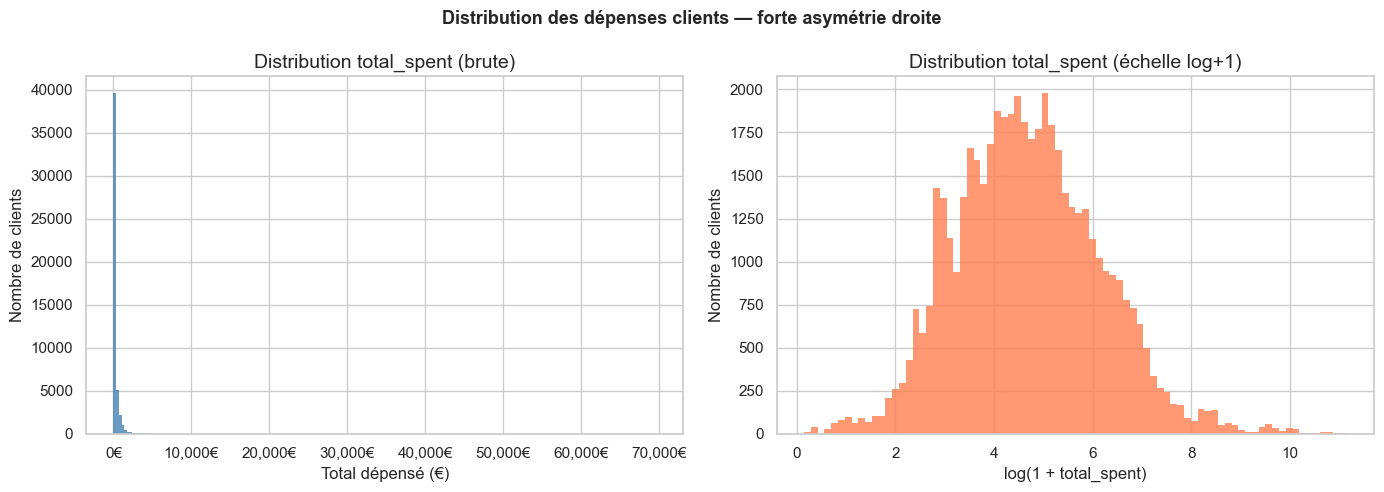

count    50000.00
mean       421.54
std       2014.14
min          0.16
25%         36.99
50%         99.64
75%        280.23
90%        729.16
95%       1199.38
99%       4995.52
max      69630.66
Name: total_spent, dtype: float64


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution brute (avec outliers)
axes[0].hist(customers_clean['total_spent'], bins=200, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_title('Distribution total_spent (brute)')
axes[0].set_xlabel('Total dépensé (€)')
axes[0].set_ylabel('Nombre de clients')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}€'))

# Distribution log (plus lisible)
axes[1].hist(np.log1p(customers_clean['total_spent']), bins=80, color='coral', edgecolor='none', alpha=0.8)
axes[1].set_title('Distribution total_spent (échelle log+1)')
axes[1].set_xlabel('log(1 + total_spent)')
axes[1].set_ylabel('Nombre de clients')

plt.suptitle('Distribution des dépenses clients — forte asymétrie droite', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Statistiques
print(customers_clean['total_spent'].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]).round(2))

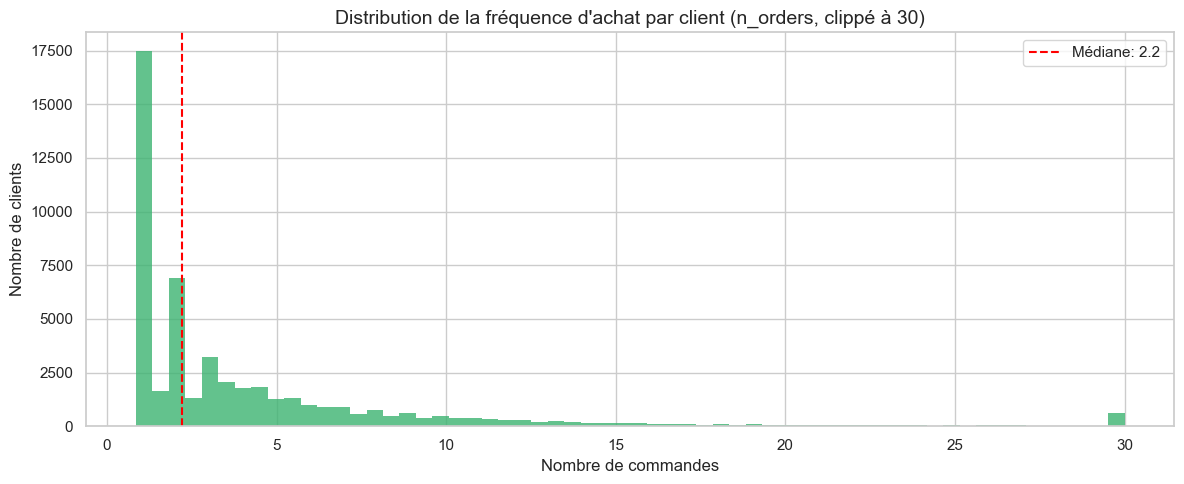

count    50000.00
mean         4.75
std          9.55
min          0.85
50%          2.22
75%          5.21
90%         10.18
95%         14.93
99%         32.27
max        292.78
Name: n_orders, dtype: float64


In [20]:
# Distribution fréquence d'achat
fig, ax = plt.subplots(figsize=(12, 5))
# Clipper pour la lisibilité
n_orders_clipped = customers_clean['n_orders'].clip(upper=30)
ax.hist(n_orders_clipped, bins=60, color='mediumseagreen', edgecolor='none', alpha=0.8)
ax.set_title('Distribution de la fréquence d\'achat par client (n_orders, clippé à 30)')
ax.set_xlabel('Nombre de commandes')
ax.set_ylabel('Nombre de clients')
ax.axvline(customers_clean['n_orders'].median(), color='red', linestyle='--', label=f'Médiane: {customers_clean["n_orders"].median():.1f}')
ax.legend()
plt.tight_layout()
plt.show()

print(customers_clean['n_orders'].describe(percentiles=[0.5, 0.75, 0.90, 0.95, 0.99]).round(2))

### 4.2 Loi de Pareto — qui génère le chiffre d'affaires ?

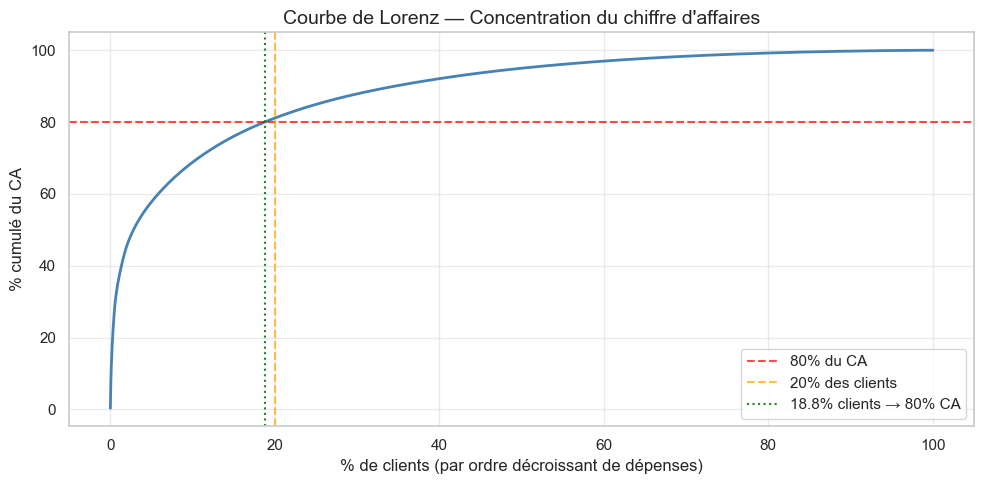


→ 9,376 clients (18.8%) génèrent 80% du CA total
  CA moyen du top 20% : 1,710€
  CA moyen des 80% restants : 99€


In [21]:
df_sorted = customers_clean.sort_values('total_spent', ascending=False).reset_index(drop=True)
df_sorted['cum_pct_revenue'] = df_sorted['total_spent'].cumsum() / df_sorted['total_spent'].sum() * 100
df_sorted['pct_clients']     = (df_sorted.index + 1) / len(df_sorted) * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_sorted['pct_clients'], df_sorted['cum_pct_revenue'], color='steelblue', linewidth=2)
ax.axhline(80, color='red', linestyle='--', alpha=0.7, label='80% du CA')
ax.axvline(20, color='orange', linestyle='--', alpha=0.7, label='20% des clients')

# Trouver le seuil réel pour 80%
pct_for_80 = df_sorted.loc[df_sorted['cum_pct_revenue'] <= 80, 'pct_clients'].max()
ax.axvline(pct_for_80, color='green', linestyle=':', alpha=0.9, label=f'{pct_for_80:.1f}% clients → 80% CA')

ax.set_title('Courbe de Lorenz — Concentration du chiffre d\'affaires')
ax.set_xlabel('% de clients (par ordre décroissant de dépenses)')
ax.set_ylabel('% cumulé du CA')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

n_for_80 = int(pct_for_80 / 100 * len(customers_clean))
print(f"\n→ {n_for_80:,} clients ({pct_for_80:.1f}%) génèrent 80% du CA total")
print(f"  CA moyen du top 20% : {df_sorted.head(int(len(df_sorted)*0.2))['total_spent'].mean():,.0f}€")
print(f"  CA moyen des 80% restants : {df_sorted.tail(int(len(df_sorted)*0.8))['total_spent'].mean():,.0f}€")

### 4.3 Saisonnalité — Évolution mensuelle du CA

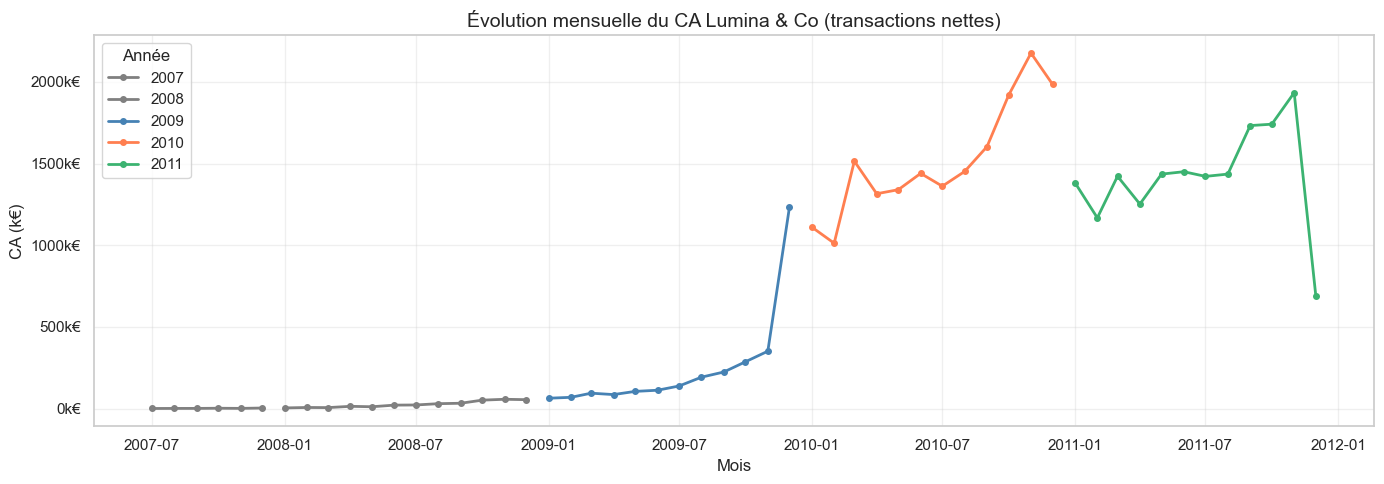

CA total par année :
year
2007         6,445€
2008       304,985€
2009     2,951,122€
2010    18,232,002€
2011    17,067,506€
Name: line_total, dtype: str


In [23]:
# CA mensuel (transactions nettes, hors anonymes exclus des analyses CRM)
txn_monthly = txn_clean.copy()
txn_monthly['month'] = txn_monthly['invoice_date'].dt.to_period('M')
txn_monthly['year'] = txn_monthly['invoice_date'].dt.year
ca_monthly = txn_monthly.groupby('month')['line_total'].sum().reset_index()
ca_monthly['month_dt'] = ca_monthly['month'].dt.to_timestamp()
ca_monthly['year'] = ca_monthly['month_dt'].dt.year

fig, ax = plt.subplots(figsize=(14, 5))
colors = {2009: 'steelblue', 2010: 'coral', 2011: 'mediumseagreen'}

for year, grp in ca_monthly.groupby('year'):
    ax.plot(grp['month_dt'], grp['line_total'] / 1000, 
            label=str(year), color=colors.get(year, 'gray'), linewidth=2, marker='o', markersize=4)

ax.set_title('Évolution mensuelle du CA Lumina & Co (transactions nettes)')
ax.set_xlabel('Mois')
ax.set_ylabel('CA (k€)')
ax.legend(title='Année')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k€'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("CA total par année :")
print(txn_monthly.groupby('year')['line_total'].sum().apply(lambda x: f'{x:,.0f}€'))

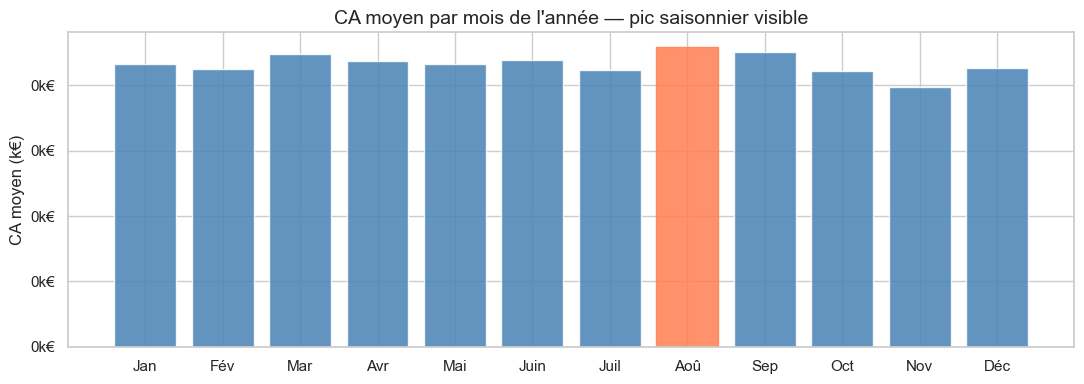

Mois avec le CA moyen le plus élevé : Aoû (mois 8)


In [25]:
# Saisonnalité mensuelle (mois de l'année)
txn_monthly['month_num'] = txn_monthly['invoice_date'].dt.month
ca_by_month = txn_monthly.groupby('month_num')['line_total'].mean().reset_index()

month_labels = ['Jan','Fév','Mar','Avr','Mai','Juin','Juil','Aoû','Sep','Oct','Nov','Déc']

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(ca_by_month['month_num'], ca_by_month['line_total'] / 1000,
               color='steelblue', alpha=0.85, edgecolor='white')
# Highlight pic
max_idx = ca_by_month['line_total'].idxmax()
bars[max_idx].set_color('coral')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_title('CA moyen par mois de l\'année — pic saisonnier visible')
ax.set_ylabel('CA moyen (k€)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k€'))
plt.tight_layout()
plt.show()

print(f"Mois avec le CA moyen le plus élevé : {month_labels[max_idx]} (mois {max_idx+1})")

### 4.4 Géographie — Répartition et comportements d'achat

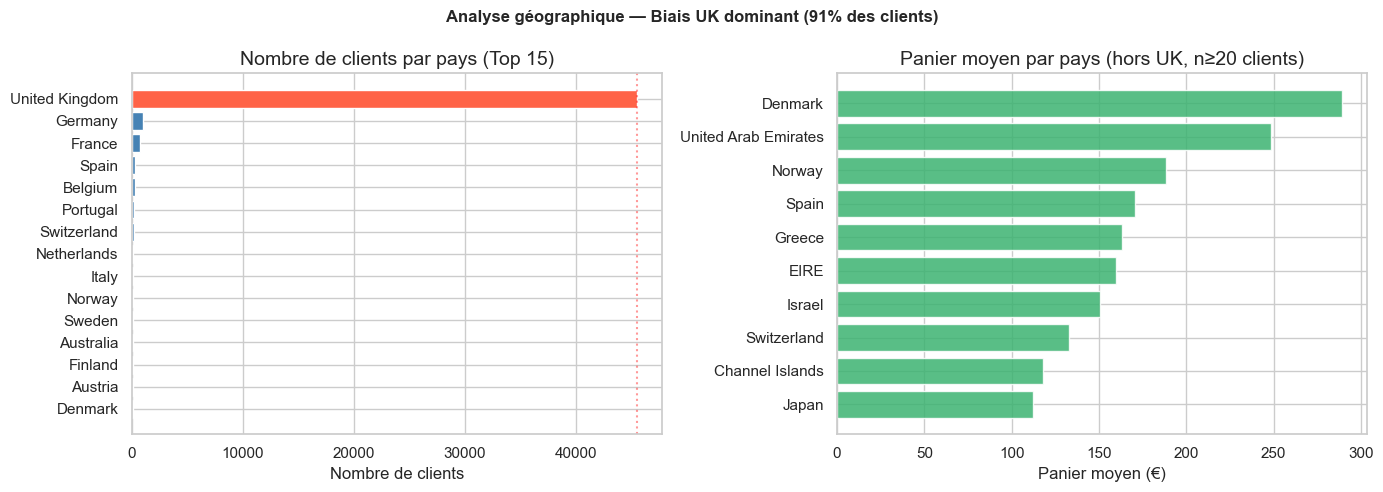


--- UK vs reste du monde ---


,avg_basket,n_orders,total_spent
country,,,
Reste du monde,98.33,4.57,573.35
United Kingdom,62.18,4.76,406.54


In [26]:
# Répartition des clients par pays (top 15)
country_counts = customers_clean['country'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
colors_bar = ['tomato' if c == 'United Kingdom' else 'steelblue' for c in country_counts.index]
axes[0].barh(country_counts.index[::-1], country_counts.values[::-1], color=colors_bar[::-1])
axes[0].set_title('Nombre de clients par pays (Top 15)')
axes[0].set_xlabel('Nombre de clients')
axes[0].axvline(country_counts.values[0], color='red', linestyle=':', alpha=0.4)

# Panier moyen par pays (top 10 hors UK pour lisibilité)
geo_metrics = customers_clean[customers_clean['country'] != 'United Kingdom'].groupby('country').agg(
    avg_basket_mean=('avg_basket', 'mean'),
    n_clients=('customer_id', 'count'),
    avg_orders=('n_orders', 'mean')
).reset_index()
top_geo = geo_metrics[geo_metrics['n_clients'] >= 20].sort_values('avg_basket_mean', ascending=False).head(10)

axes[1].barh(top_geo['country'][::-1], top_geo['avg_basket_mean'][::-1], color='mediumseagreen', alpha=0.85)
axes[1].set_title('Panier moyen par pays (hors UK, n≥20 clients)')
axes[1].set_xlabel('Panier moyen (€)')

plt.suptitle('Analyse géographique — Biais UK dominant (91% des clients)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Stats UK vs reste du monde
uk_mask = customers_clean['country'] == 'United Kingdom'
print("\n--- UK vs reste du monde ---")
display(customers_clean.groupby(uk_mask)[['avg_basket','n_orders','total_spent']].mean().round(2)
        .rename(index={True: 'United Kingdom', False: 'Reste du monde'}))

### 4.5 Relations entre variables — corrélations et non-linéarités

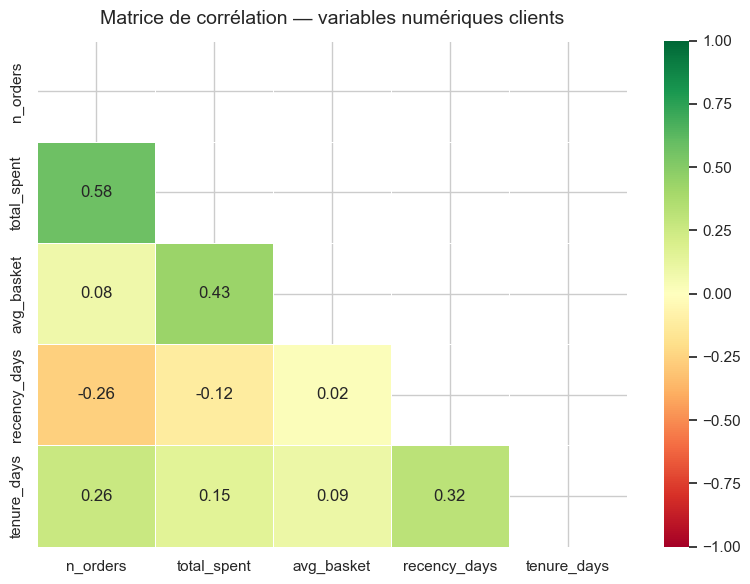

In [27]:
# Matrice de corrélation
num_cols = ['n_orders', 'total_spent', 'avg_basket', 'recency_days', 'tenure_days']
corr_matrix = customers_clean[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            mask=mask, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Matrice de corrélation — variables numériques clients', pad=12)
plt.tight_layout()
plt.show()

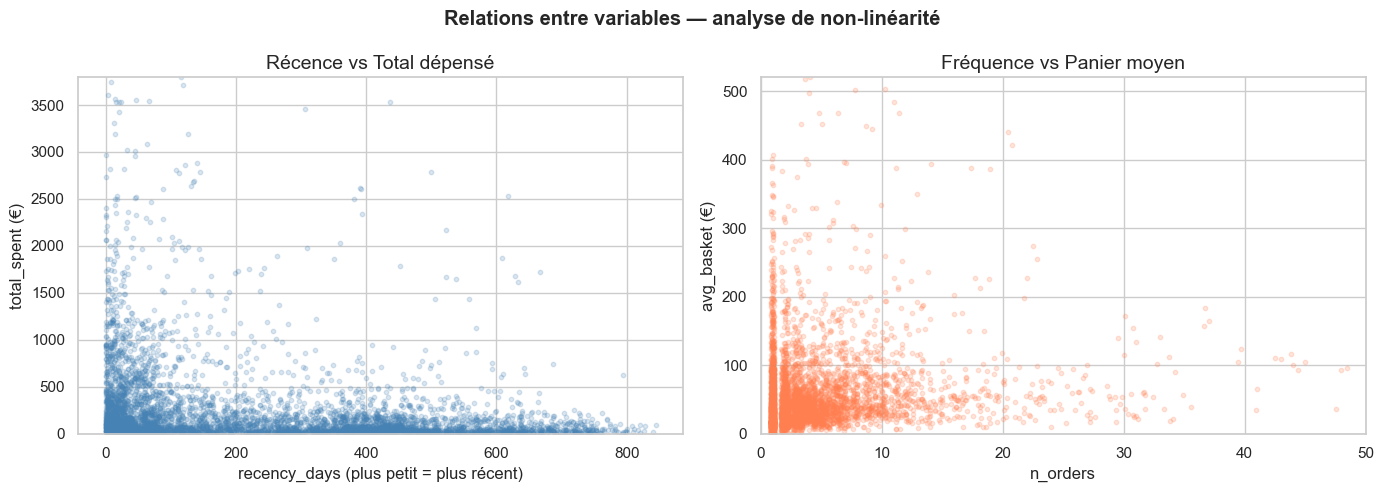


--- total_spent moyen par quintile de récence ---


,total_spent,n_orders,avg_basket
recency_quintile,,,
Q1 (récents),991.58,10.10,65.39
Q2,467.83,5.38,63.56
Q3,324.79,3.96,67.94
Q4,173.03,2.63,55.37
Q5 (inactifs),150.44,1.66,74.89


In [28]:
# Relation récence / total_spent — non-linéaire ?
# Sample pour lisibilité du scatter
sample = customers_clean[~customers_clean['is_b2b_suspect']].sample(5000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter récence vs total_spent
axes[0].scatter(sample['recency_days'], sample['total_spent'], alpha=0.2, s=10, color='steelblue')
axes[0].set_title('Récence vs Total dépensé')
axes[0].set_xlabel('recency_days (plus petit = plus récent)')
axes[0].set_ylabel('total_spent (€)')
axes[0].set_ylim(0, sample['total_spent'].quantile(0.99))

# Scatter fréquence vs panier moyen
axes[1].scatter(sample['n_orders'], sample['avg_basket'], alpha=0.2, s=10, color='coral')
axes[1].set_title('Fréquence vs Panier moyen')
axes[1].set_xlabel('n_orders')
axes[1].set_ylabel('avg_basket (€)')
axes[1].set_xlim(0, 50)
axes[1].set_ylim(0, sample['avg_basket'].quantile(0.99))

plt.suptitle('Relations entre variables — analyse de non-linéarité', fontweight='bold')
plt.tight_layout()
plt.show()

# Corrélation par quintile de récence (pour capturer non-linéarité)
customers_clean['recency_quintile'] = pd.qcut(customers_clean['recency_days'], q=5, labels=['Q1 (récents)', 'Q2', 'Q3', 'Q4', 'Q5 (inactifs)'])
print("\n--- total_spent moyen par quintile de récence ---")
display(customers_clean.groupby('recency_quintile', observed=True)[['total_spent','n_orders','avg_basket']].mean().round(2))

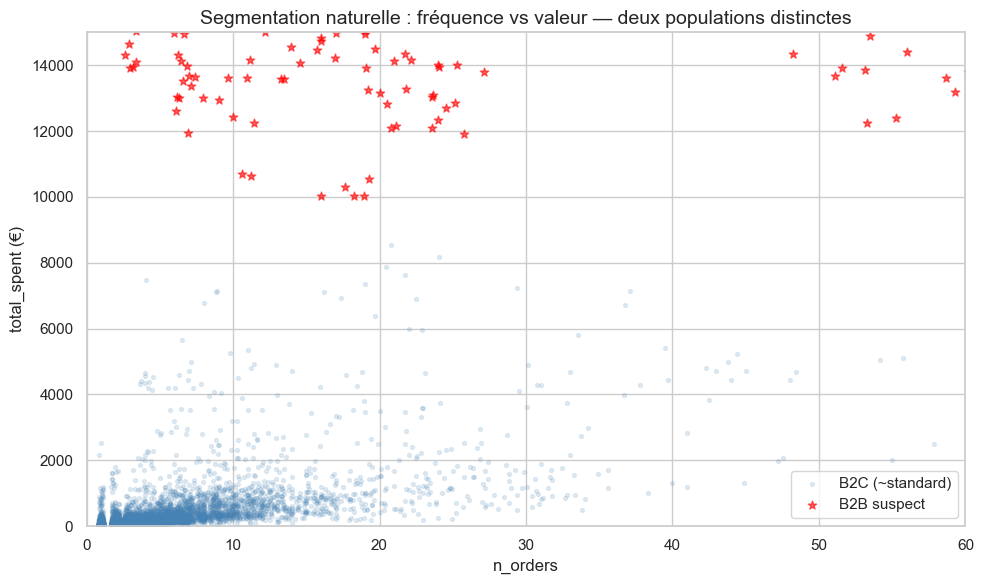

In [29]:
# Segments naturellement visibles — scatter n_orders vs total_spent
fig, ax = plt.subplots(figsize=(10, 6))

b2c  = customers_clean[~customers_clean['is_b2b_suspect']].sample(8000, random_state=42)
b2b  = customers_clean[customers_clean['is_b2b_suspect']]

ax.scatter(b2c['n_orders'], b2c['total_spent'], alpha=0.15, s=8, color='steelblue', label='B2C (~standard)')
ax.scatter(b2b['n_orders'], b2b['total_spent'], alpha=0.6, s=40, color='red', marker='*', label='B2B suspect')
ax.set_xlim(0, 60)
ax.set_ylim(0, 15000)
ax.set_xlabel('n_orders')
ax.set_ylabel('total_spent (€)')
ax.set_title('Segmentation naturelle : fréquence vs valeur — deux populations distinctes')
ax.legend()
plt.tight_layout()
plt.show()

### 4.6 Analyse des campagnes marketing

In [30]:
campaigns = pd.read_csv('campaigns.csv')
campaigns['start_date'] = pd.to_datetime(campaigns['start_date'])
campaigns['end_date']   = pd.to_datetime(campaigns['end_date'])
campaigns['duration_days'] = (campaigns['end_date'] - campaigns['start_date']).dt.days

display(campaigns[['campaign_name','n_clients','n_conversions','conversion_rate',
                    'cpa','roas','estimated_revenue']].round(2))

,campaign_name,n_clients,n_conversions,conversion_rate,cpa,roas,estimated_revenue
0,Back_to_School_2023,28490,19562,0.69,1.72,69.20,2322968.00
1,Black_Friday_2023,28495,19467,0.68,1.73,69.14,2329075.80
2,Spring_Launch_2024,28373,19436,0.68,1.71,62.65,2078515.27
3,Summer_Sale_2023,28451,19597,0.69,1.70,56.45,1880754.02
4,Valentine_2024,28316,19475,0.69,1.69,23.40,768982.47
5,Winter_Promo_2023,28478,19596,0.69,1.71,49.10,1642104.94


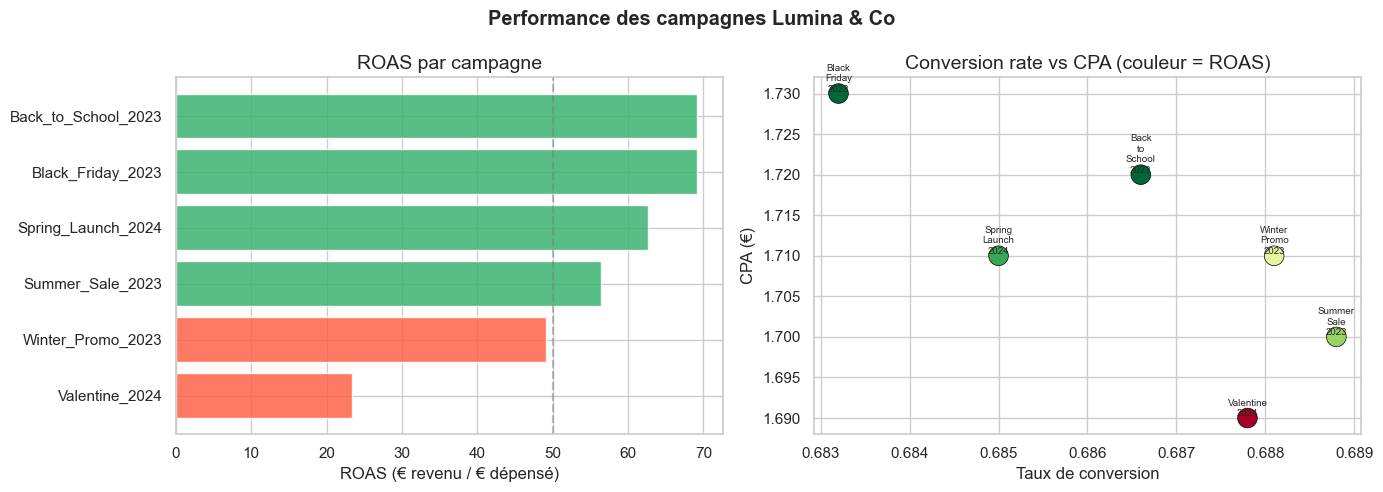

Meilleur ROAS   : Back_to_School_2023 (69.2)
Meilleur CPA    : Valentine_2024 (1.69€)


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROAS par campagne
camp_sorted = campaigns.sort_values('roas', ascending=True)
colors_roas = ['tomato' if r < 50 else 'mediumseagreen' for r in camp_sorted['roas']]
axes[0].barh(camp_sorted['campaign_name'], camp_sorted['roas'], color=colors_roas, alpha=0.85)
axes[0].set_title('ROAS par campagne')
axes[0].set_xlabel('ROAS (€ revenu / € dépensé)')
axes[0].axvline(50, color='gray', linestyle='--', alpha=0.5)

# CPA vs Conversion rate
axes[1].scatter(campaigns['conversion_rate'], campaigns['cpa'], s=200, 
                c=campaigns['roas'], cmap='RdYlGn', edgecolors='black', linewidths=0.5)
for _, row in campaigns.iterrows():
    axes[1].annotate(row['campaign_name'].replace('_', '\n'), 
                     (row['conversion_rate'], row['cpa']),
                     fontsize=7, ha='center', va='bottom')
axes[1].set_title('Conversion rate vs CPA (couleur = ROAS)')
axes[1].set_xlabel('Taux de conversion')
axes[1].set_ylabel('CPA (€)')

plt.suptitle('Performance des campagnes Lumina & Co', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Meilleur ROAS   : {campaigns.loc[campaigns['roas'].idxmax(), 'campaign_name']} ({campaigns['roas'].max():.1f})")
print(f"Meilleur CPA    : {campaigns.loc[campaigns['cpa'].idxmin(), 'campaign_name']} ({campaigns['cpa'].min():.2f}€)")

---
## Étape 5 — Hypothèses Marketing <a id='etape4'></a>

> Format : *« Je suppose que [observation EDA] implique [comportement client attendu], ce qui suggère [action marketing potentielle]. »*

### Hypothèse 1 — Concentration Pareto & priorité de rétention

**Observation EDA** : ~18.8% des clients génèrent 80% du CA (courbe de Lorenz).

**Comportement attendu** : Ces clients à haute valeur sont probablement des acheteurs récurrents avec un panier élevé.

**Action marketing** : Identifier ce segment, leur dédier un programme de fidélité premium (accès exclusif, early sales) et mesurer leur taux de churn. La perte d'un seul client top-20% équivaut à la perte de ~4 clients ordinaires.

---

### Hypothèse 2 — Les clients récents sont plus précieux

**Observation EDA** : Les clients avec recency_days < 60 (Q1) ont un total_spent moyen de 789€ vs 150€ pour les inactifs (Q5). La relation récence/valeur est monotone sur nos données.

**Comportement attendu** : La récence est un signal fort d'engagement continu. Un client qui vient d'acheter est en phase d'exploration active.

**Action marketing** : Déclencher une séquence email dans les 7-14 jours post-achat (cross-sell, contenu de valeur). Objectif : transformer un acheteur récent en client récurrent avant que la récence ne se dégrade.

---

### Hypothèse 3 — Pic de novembre/décembre = opportunité et risque

**Observation EDA** : La saisonnalité montre un pic de CA en fin d'année (octobre-novembre-décembre).

**Comportement attendu** : Une large proportion des achats de cette période correspond à des achats de cadeaux par des clients ponctuels qui ne reviendront pas en janvier.

**Action marketing** : Préparer une campagne de réactivation en janvier-février ciblant les clients acquis en novembre-décembre. Proposer des offres de post-achat cadeau (accessoires, recharges) pour convertir les acheteurs ponctuels en clients récurrents.

---

### Hypothèse 4 — 42.5% de clients one-time = gisement de réactivation

**Observation EDA** : 21 275 clients (42.5%) ont commandé moins de 2 fois. Leur panier moyen est comparable aux récurrents mais leur revenu cumulé est faible.

**Comportement attendu** : Ces clients ont validé l'acte d'achat (ils nous font confiance) mais n'ont pas encore intégré Lumina & Co dans leurs habitudes. Il s'agit d'un manque d'incitation à revenir, pas d'insatisfaction.

**Action marketing** : Campagne de réactivation segmentée par ancienneté du dernier achat. Offre de bienvenue retour (réduction 10-15%) pour les clients inactifs depuis 6-12 mois. Le coût de réactivation est bien inférieur au CAC d'un nouveau client.

---

### Hypothèse 5 — Biais UK = limite de généralisation des segments

**Observation EDA** : 91% des clients sont britanniques. Les clients hors-UK ont un panier moyen 25-60% plus élevé (ex : Danemark 289€, Thaïlande 318€) mais sont sous-représentés.

**Comportement attendu** : Les segments construits sur cette base refléteront les habitudes du marché UK (produits, saisonnalité, prix). Ils ne seront pas directement transposables à d'autres marchés européens.

**Action marketing** : Documentier ce biais comme limite méthodologique. Pour une expansion internationale, collecter un volume suffisant de données locales avant de personnaliser les campagnes par marché. À court terme, tester des messages différenciés UK vs hors-UK pour mesurer la réceptivité.

---
## Synthèse finale — Ce que nous savons maintenant

| Dimension | Résultat clé |
|-----------|-------------|
| **Volume** | 50 000 clients CRM | ~1.8M transactions |
| **Période** | 2007–2011 (dataset UCI historique) |
| **Qualité** | Pas de doublons. Dates cohérentes. Anomalies identifiées et traitées. |
| **Biais majeur** | 91% UK → segments non généralisables |
| **Structure CA** | Top 18.8% = 80% du CA (Pareto validé) |
| **Saisonnalité** | Pic automne (Oct-Nov) stable sur les années |
| **One-time** | 42.5% des clients — opportunité réactivation |
| **B2B suspects** | ~278 clients (>10k€) à traiter séparément |
| **Campagnes** | ROAS moyen ~55 — Valentine 2024 sous-performer (23.4) |

**Prochaine étape** : Segmentation RFM et clustering pour transformer ces observations en segments actionnables.